### D:\Study\Project\venv\Scripts\activate                 run this in terminal to activate venv
#   c:\users\amr samy\appdata\local\pip\cache              pip cache

In [1]:
import os
import shutil
import random

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [2]:
from torchvision import transforms

train_transform = transforms.Compose([
    # Resize already done in preprocessing

    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))],
        p=0.25
    ),

    transforms.RandomRotation(degrees=3),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [3]:
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root=r"D:\Study\ID_Checking\Data\processed\train",
    transform=train_transform
)

val_dataset = ImageFolder(
    root=r"D:\Study\ID_Checking\Data\processed\val",
    transform=eval_transform
)

test_dataset = ImageFolder(
    root=r"D:\Study\ID_Checking\Data\processed\test",
    transform=eval_transform
)

In [5]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [6]:
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [7]:
images, labels = next(iter(train_loader))
print(images.shape)   # [B, 3, 224, 224]
print(labels)

torch.Size([16, 3, 224, 224])
tensor([1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1])


try (MobileNetV3 Small)

In [8]:
import torch
import torch.nn as nn
from torchvision import models

print(torch.__version__)

2.5.1+cu121


In [9]:
model = models.mobilenet_v3_small(pretrained=True)

d:\Study\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Study\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
print(model.classifier)

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=1000, bias=True)
)


out_features=1000   ==> 2 ID or Not

In [11]:
model.classifier[3] = nn.Linear(1024, 2)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(device)

cuda


In [13]:
criterion = nn.CrossEntropyLoss()

In [14]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [15]:
def accuracy_fn(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

In [16]:
import torch

num_epochs = 10

for epoch in range(num_epochs):
    print(f"\n===== Epoch [{epoch+1}/{num_epochs}] =====")

    # ======================
    # TRAIN
    # ======================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        # ---- Batch verbose ----
        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(train_loader):
            print(
                f"Train | Batch [{batch_idx+1}/{len(train_loader)}] "
                f"Loss: {loss.item():.4f}"
            )

    train_loss /= train_total
    train_acc = train_correct / train_total

    print(
        f"Train Summary → "
        f"Loss: {train_loss:.4f} | "
        f"Acc: {train_acc:.4f}"
    )

    # ======================
    # VALIDATION
    # ======================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(
        f"Val   Summary → "
        f"Loss: {val_loss:.4f} | "
        f"Acc: {val_acc:.4f}"
    )


===== Epoch [1/10] =====
Train | Batch [10/49] Loss: 0.3079
Train | Batch [20/49] Loss: 0.2449
Train | Batch [30/49] Loss: 0.0931
Train | Batch [40/49] Loss: 0.0238
Train | Batch [49/49] Loss: 0.4305
Train Summary → Loss: 0.1998 | Acc: 0.9519
Val   Summary → Loss: 0.0658 | Acc: 0.9922

===== Epoch [2/10] =====
Train | Batch [10/49] Loss: 0.0175
Train | Batch [20/49] Loss: 0.0113
Train | Batch [30/49] Loss: 0.0063
Train | Batch [40/49] Loss: 0.0061
Train | Batch [49/49] Loss: 0.3243
Train Summary → Loss: 0.0304 | Acc: 0.9935
Val   Summary → Loss: 0.0162 | Acc: 0.9961

===== Epoch [3/10] =====
Train | Batch [10/49] Loss: 0.0027
Train | Batch [20/49] Loss: 0.0055
Train | Batch [30/49] Loss: 0.0161
Train | Batch [40/49] Loss: 0.0166
Train | Batch [49/49] Loss: 0.2645
Train Summary → Loss: 0.0148 | Acc: 0.9961
Val   Summary → Loss: 0.0071 | Acc: 0.9961

===== Epoch [4/10] =====
Train | Batch [10/49] Loss: 0.0055
Train | Batch [20/49] Loss: 0.0054
Train | Batch [30/49] Loss: 0.2274
Train | 

In [17]:
from sklearn.metrics import classification_report

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [18]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["ID", "NOTID"]
    )
)

              precision    recall  f1-score   support

          ID       1.00      1.00      1.00       118
       NOTID       1.00      1.00      1.00       138

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256



In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

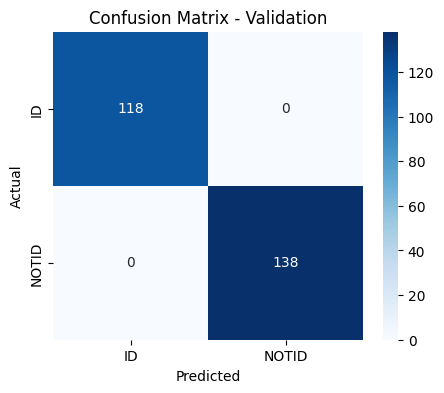

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ID", "NOTID"],
    yticklabels=["ID", "NOTID"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Validation")
plt.show()

In [ ]:
torch.save(model.state_dict(), "id_check_v1.pth")

---------------------------------------------------------------------------------------------------------------------------------------------

build model from scratch

In [22]:
import torch.nn as nn
import torch.nn.functional as F

In [23]:
class IDClassifierScratch(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [24]:
model_scratch = IDClassifierScratch().to(device)

In [25]:
optimizer_scratch = torch.optim.Adam(
    model_scratch.parameters(),
    lr=1e-3
)

In [26]:
num_epochs = 15
patience = 3

best_val_loss = float("inf")
patience_counter = 0
best_epoch = 0

for epoch in range(num_epochs):

    # ======================
    # TRAIN
    # ======================
    model_scratch.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_scratch.zero_grad()

        outputs = model_scratch(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_scratch.step()

        train_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ======================
    # VALIDATION
    # ======================
    model_scratch.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model_scratch(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # ======================
    # PRINT (TensorFlow style)
    # ======================
    print(
        f"Epoch {epoch+1}/{num_epochs} - "
        f"loss: {train_loss:.4f} - "
        f"acc: {train_acc:.4f} - "
        f"val_loss: {val_loss:.4f} - "
        f"val_acc: {val_acc:.4f}"
    )

    # ======================
    # EARLY STOPPING CHECK
    # ======================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_epoch = epoch + 1

        torch.save(
            model_scratch.state_dict(),
            "id_scratch_best.pth"
        )
    else:
        patience_counter += 1

        if patience_counter >= patience:
            print(
                f"\n⏹ Early Stopping triggered "
                f"at epoch {epoch+1}. "
                f"Best epoch was {best_epoch}."
            )
            break


Epoch 1/15 - loss: 0.3557 - acc: 0.8674 - val_loss: 0.2059 - val_acc: 0.9258
Epoch 2/15 - loss: 0.2336 - acc: 0.9155 - val_loss: 0.3651 - val_acc: 0.9023
Epoch 3/15 - loss: 0.2277 - acc: 0.9129 - val_loss: 0.1506 - val_acc: 0.9492
Epoch 4/15 - loss: 0.1358 - acc: 0.9506 - val_loss: 0.1803 - val_acc: 0.9297
Epoch 5/15 - loss: 0.1440 - acc: 0.9441 - val_loss: 0.2124 - val_acc: 0.9141
Epoch 6/15 - loss: 0.1178 - acc: 0.9571 - val_loss: 0.1675 - val_acc: 0.9688

⏹ Early Stopping triggered at epoch 6. Best epoch was 3.


Evaluating

In [27]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_scratch(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["ID", "NOT_ID"]
    )
)

              precision    recall  f1-score   support

          ID       1.00      0.93      0.96       118
      NOT_ID       0.95      1.00      0.97       138

    accuracy                           0.97       256
   macro avg       0.97      0.97      0.97       256
weighted avg       0.97      0.97      0.97       256



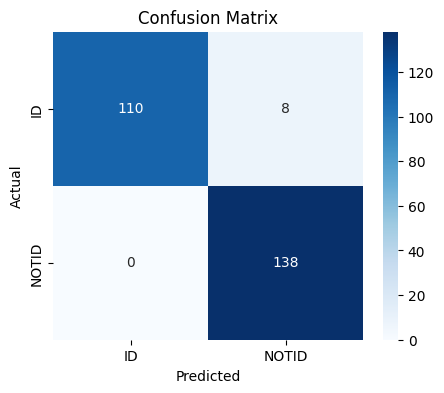

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ID", "NOTID"],
    yticklabels=["ID", "NOTID"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()